In [527]:
import signal_gen_toolbox as sgt

import importlib
importlib.reload(sgt)

fn_yaml = "config.yaml"

N_loadcases = 5


In [528]:
config = sgt.load_config(fn_yaml)

{'signals': {'sig1': {'display_name': 'signal_1',
                      'units': 'F',
                      'parameters': {'magnitude': {'distribution_type': 'uniform',
                                                   'min_value': 0,
                                                   'max_value': 100},
                                     'rate_of_change': {'distribution_type': 'uniform',
                                                        'min_value': -10,
                                                        'max_value': 10,
                                                        'set_to_0_probability': 0.3}},
                      'plot_color': 'red'},
             'sig2': {'display_name': 'signal_2',
                      'units': 'F',
                      'parameters': {'magnitude': {'distribution_type': 'uniform',
                                                   'min_value': 0,
                                                   'max_value': 200},
                      

In [529]:
df_samples = sgt.generate_samples(config, N = N_loadcases)
print(df_samples)

              sig1                                                             \
         magnitude rate_of_change ramp_start_time ramp_duration hold_duration   
loadcase                                                                        
0            100.0            0.0           10.00          50.0          12.5   
1              0.0           -5.0            7.75          37.5          37.5   
2             25.0           10.0            3.25          12.5           0.0   
3             50.0          -10.0            5.50          25.0          50.0   
4             75.0            5.0            1.00           0.0          25.0   

                       sig2                                               \
         end_time magnitude rate_of_change ramp_start_time ramp_duration   
loadcase                                                                   
0           200.0       0.0            0.0           10.00          12.5   
1           200.0     200.0           10.0     

In [ ]:
idx = 2
df_signals, df_parameters = sgt.generate_ramp_signals(df_samples, config, idx)
print(df_signals)



         sig1  sig2  sig3   sig4   sig5
t                                      
0.00     25.0  50.0   0.0   25.0   50.0
3.25     25.0  50.0   0.0   25.0   50.0
5.50     47.5  50.0   0.0    2.5   50.0
7.75     70.0  50.0   0.0   20.0   70.0
10.75   100.0  35.0   0.0   65.0  100.0
15.75   100.0  10.0   0.0   90.0  100.0
17.75   100.0   0.0   0.0  100.0  100.0
18.00   100.0   0.0   0.0  100.0  100.0
20.75   100.0   0.0   0.0  100.0  100.0
28.25    25.0   0.0   0.0   25.0   25.0
55.50    25.0   0.0   0.0   25.0   25.0
57.75    25.0   0.0   0.0   25.0   25.0
68.00    25.0   0.0   0.0   25.0   25.0
107.75   25.0   0.0   0.0   25.0   25.0
147.75   25.0   0.0   0.0   25.0   25.0
157.75   25.0  50.0   0.0   25.0   50.0
200.00   25.0  50.0   0.0   25.0   50.0


In [533]:
import pandas as pd

df_all = pd.DataFrame(index = range(N_loadcases), columns = ['loadcase_name', 'df_signals', 'df_parameters'])

for i in range(N_loadcases):
    loadcase_name = f"ramp_{i+1:05d}"
    df_signals, df_parameters = sgt.generate_ramp_signals(df_samples, config, i)
    df_all.loc[i,  ['loadcase_name', 'df_signals', 'df_parameters']] = [loadcase_name, df_signals, df_parameters]

print(df_all.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   loadcase_name  5 non-null      object
 1   df_signals     5 non-null      object
 2   df_parameters  5 non-null      object
dtypes: object(3)
memory usage: 252.0+ bytes
None


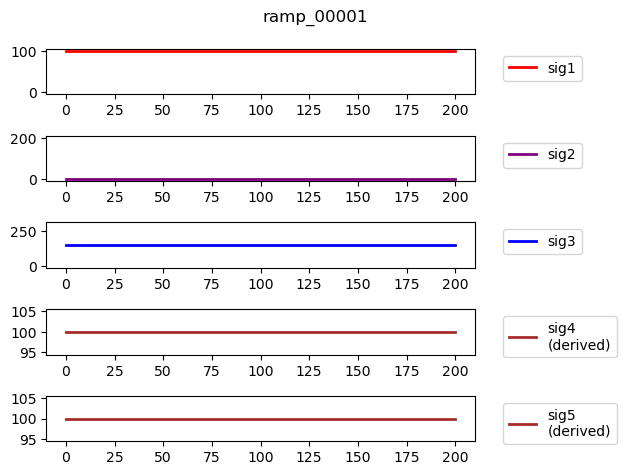

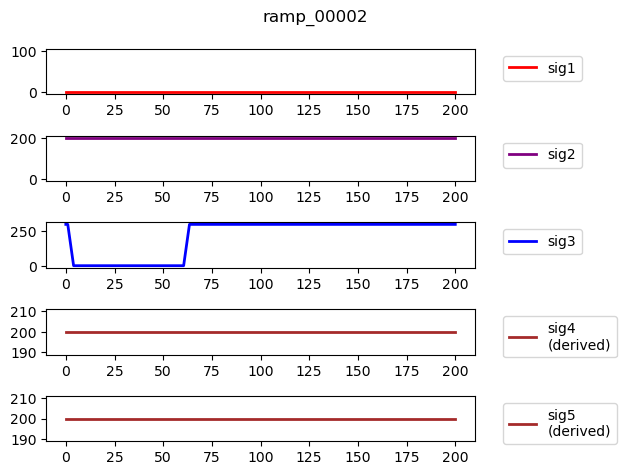

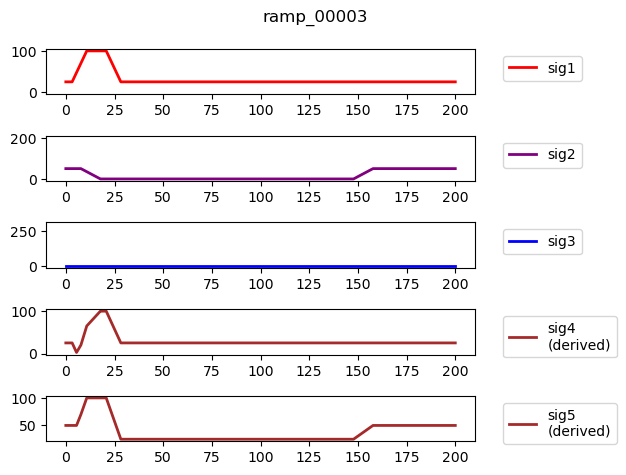

In [534]:
for i in range(3):
    loadcase_name = df_all.loc[i, 'loadcase_name']
    df_signals = df_all.loc[i, 'df_signals']
    sgt.plot_loadcase(df_signals, config, loadcase_name = loadcase_name)